<a href="https://colab.research.google.com/github/Rut092/AI-Journey-Practice/blob/main/Practice_till_now(Linear%2CMulti%2CPolynomial%2CSVM%2CDT%2CRF%2CEval_REG%2CLogReg%2CKNN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import SVR,SVC
from sklearn.tree import DecisionTreeRegressor,plot_tree,DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
data = pd.read_csv("Data.csv")

In [ ]:
print(data)

   Country   Age   Salary Purchased
0   France  44.0  72000.0        No
1    Spain  27.0  48000.0       Yes
2  Germany  30.0  54000.0        No
3    Spain  38.0  61000.0        No
4  Germany  40.0      NaN       Yes
5   France  35.0  58000.0       Yes
6    Spain   NaN  52000.0        No
7   France  48.0  79000.0       Yes
8  Germany  50.0  83000.0        No
9   France  37.0  67000.0       Yes


In [ ]:
X = data.iloc[:,:-1].values
print(X)

[['France' 44.0 72000.0]
 ['Spain' 27.0 48000.0]
 ['Germany' 30.0 54000.0]
 ['Spain' 38.0 61000.0]
 ['Germany' 40.0 nan]
 ['France' 35.0 58000.0]
 ['Spain' nan 52000.0]
 ['France' 48.0 79000.0]
 ['Germany' 50.0 83000.0]
 ['France' 37.0 67000.0]]


In [ ]:
y = data.iloc[:,-1].values
print(y)

['No' 'Yes' 'No' 'No' 'Yes' 'Yes' 'No' 'Yes' 'No' 'Yes']


In [ ]:
si = SimpleImputer(missing_values = np.nan,strategy = "mean")

In [ ]:
X[:,1:] = si.fit_transform(X[:,1:])

In [ ]:
print(X)

[['France' 44.0 72000.0]
 ['Spain' 27.0 48000.0]
 ['Germany' 30.0 54000.0]
 ['Spain' 38.0 61000.0]
 ['Germany' 40.0 63777.77777777778]
 ['France' 35.0 58000.0]
 ['Spain' 38.77777777777778 52000.0]
 ['France' 48.0 79000.0]
 ['Germany' 50.0 83000.0]
 ['France' 37.0 67000.0]]


In [ ]:
ct = ColumnTransformer(transformers= [('encoder',OneHotEncoder(),[0])],remainder='passthrough')
X = np.array(ct.fit_transform(X))
print(X)

[[1.0 0.0 0.0 44.0 72000.0]
 [0.0 0.0 1.0 27.0 48000.0]
 [0.0 1.0 0.0 30.0 54000.0]
 [0.0 0.0 1.0 38.0 61000.0]
 [0.0 1.0 0.0 40.0 63777.77777777778]
 [1.0 0.0 0.0 35.0 58000.0]
 [0.0 0.0 1.0 38.77777777777778 52000.0]
 [1.0 0.0 0.0 48.0 79000.0]
 [0.0 1.0 0.0 50.0 83000.0]
 [1.0 0.0 0.0 37.0 67000.0]]


In [ ]:
le = LabelEncoder()
y = le.fit_transform(y)
print(y)

[0 1 0 0 1 1 0 1 0 1]


In [ ]:
# sc = StandardScaler()
# # note : we do not want one hot encoded value which is in the (0,1) into standardasation

# X_train[:,3:] = sc.fit_transform(X_train[:,3:])
# X_test[:,3:] = sc.transform(X_test[:,3:])

## dummy code for pre - processing of the code !

## Practicing SIMPLE LINEAR REGRESSION and Multi Linear Regression

In [ ]:
new_data = pd.read_csv("Salary_Data.csv")

In [ ]:
print(new_data)

    YearsExperience    Salary
0               1.1   39343.0
1               1.3   46205.0
2               1.5   37731.0
3               2.0   43525.0
4               2.2   39891.0
5               2.9   56642.0
6               3.0   60150.0
7               3.2   54445.0
8               3.2   64445.0
9               3.7   57189.0
10              3.9   63218.0
11              4.0   55794.0
12              4.0   56957.0
13              4.1   57081.0
14              4.5   61111.0
15              4.9   67938.0
16              5.1   66029.0
17              5.3   83088.0
18              5.9   81363.0
19              6.0   93940.0
20              6.8   91738.0
21              7.1   98273.0
22              7.9  101302.0
23              8.2  113812.0
24              8.7  109431.0
25              9.0  105582.0
26              9.5  116969.0
27              9.6  112635.0
28             10.3  122391.0
29             10.5  121872.0


In [ ]:
X,y = new_data.iloc[:,:-1].values,new_data.iloc[:,-1].values
print(X,y)

[[ 1.1]
 [ 1.3]
 [ 1.5]
 [ 2. ]
 [ 2.2]
 [ 2.9]
 [ 3. ]
 [ 3.2]
 [ 3.2]
 [ 3.7]
 [ 3.9]
 [ 4. ]
 [ 4. ]
 [ 4.1]
 [ 4.5]
 [ 4.9]
 [ 5.1]
 [ 5.3]
 [ 5.9]
 [ 6. ]
 [ 6.8]
 [ 7.1]
 [ 7.9]
 [ 8.2]
 [ 8.7]
 [ 9. ]
 [ 9.5]
 [ 9.6]
 [10.3]
 [10.5]] [ 39343.  46205.  37731.  43525.  39891.  56642.  60150.  54445.  64445.
  57189.  63218.  55794.  56957.  57081.  61111.  67938.  66029.  83088.
  81363.  93940.  91738.  98273. 101302. 113812. 109431. 105582. 116969.
 112635. 122391. 121872.]


In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [ ]:
regressor = LinearRegression()
regressor.fit(X_train,y_train)

LinearRegression()

In [ ]:
print(regressor.coef_)
print(regressor.predict([[10]]))

[9312.57512673]
[119905.85041792]


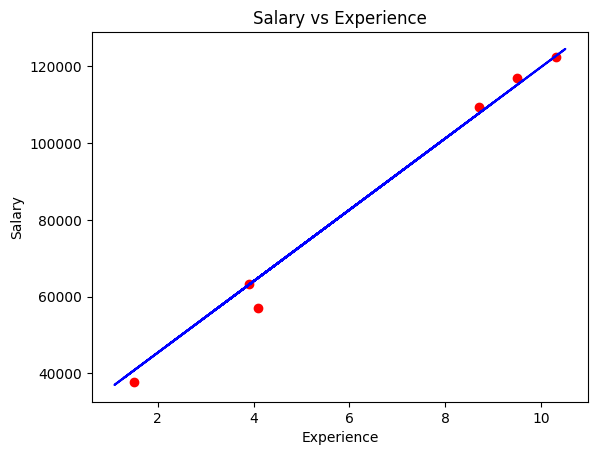

In [ ]:
plt.scatter(X_test,y_test,color = 'red')
plt.plot(X_train,regressor.predict(X_train),color = 'blue')
plt.title("Salary vs Experience")
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.show()

In [ ]:
print(regressor.predict([[5]]))

[73342.97478427]


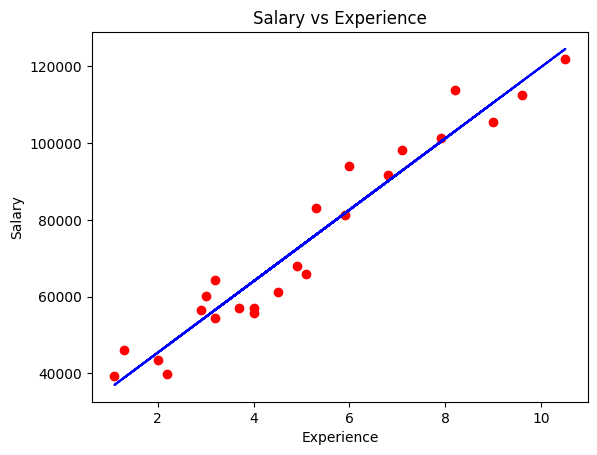

In [ ]:
plt.scatter(X_train,y_train,color = 'red')
plt.plot(X_train,regressor.predict(X_train),color = 'blue')
plt.title("Salary vs Experience")
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.show()

In [ ]:
startup_dataset = pd.read_csv("50_Startups.csv")
print(startup_dataset)

    R&D Spend  Administration  Marketing Spend       State     Profit
0   165349.20       136897.80        471784.10    New York  192261.83
1   162597.70       151377.59        443898.53  California  191792.06
2   153441.51       101145.55        407934.54     Florida  191050.39
3   144372.41       118671.85        383199.62    New York  182901.99
4   142107.34        91391.77        366168.42     Florida  166187.94
5   131876.90        99814.71        362861.36    New York  156991.12
6   134615.46       147198.87        127716.82  California  156122.51
7   130298.13       145530.06        323876.68     Florida  155752.60
8   120542.52       148718.95        311613.29    New York  152211.77
9   123334.88       108679.17        304981.62  California  149759.96
10  101913.08       110594.11        229160.95     Florida  146121.95
11  100671.96        91790.61        249744.55  California  144259.40
12   93863.75       127320.38        249839.44     Florida  141585.52
13   91992.39       

In [ ]:
X,y = startup_dataset.iloc[:,:-1].values,startup_dataset.iloc[:,-1].values
print(X,y)

[[165349.2 136897.8 471784.1 'New York']
 [162597.7 151377.59 443898.53 'California']
 [153441.51 101145.55 407934.54 'Florida']
 [144372.41 118671.85 383199.62 'New York']
 [142107.34 91391.77 366168.42 'Florida']
 [131876.9 99814.71 362861.36 'New York']
 [134615.46 147198.87 127716.82 'California']
 [130298.13 145530.06 323876.68 'Florida']
 [120542.52 148718.95 311613.29 'New York']
 [123334.88 108679.17 304981.62 'California']
 [101913.08 110594.11 229160.95 'Florida']
 [100671.96 91790.61 249744.55 'California']
 [93863.75 127320.38 249839.44 'Florida']
 [91992.39 135495.07 252664.93 'California']
 [119943.24 156547.42 256512.92 'Florida']
 [114523.61 122616.84 261776.23 'New York']
 [78013.11 121597.55 264346.06 'California']
 [94657.16 145077.58 282574.31 'New York']
 [91749.16 114175.79 294919.57 'Florida']
 [86419.7 153514.11 0.0 'New York']
 [76253.86 113867.3 298664.47 'California']
 [78389.47 153773.43 299737.29 'New York']
 [73994.56 122782.75 303319.26 'Florida']
 [67532

In [ ]:
ct = ColumnTransformer(transformers = [('encoder',OneHotEncoder(drop='first'),[3])],remainder='passthrough')
X = np.array(ct.fit_transform(X))
print(X)

[[0.0 1.0 165349.2 136897.8 471784.1]
 [0.0 0.0 162597.7 151377.59 443898.53]
 [1.0 0.0 153441.51 101145.55 407934.54]
 [0.0 1.0 144372.41 118671.85 383199.62]
 [1.0 0.0 142107.34 91391.77 366168.42]
 [0.0 1.0 131876.9 99814.71 362861.36]
 [0.0 0.0 134615.46 147198.87 127716.82]
 [1.0 0.0 130298.13 145530.06 323876.68]
 [0.0 1.0 120542.52 148718.95 311613.29]
 [0.0 0.0 123334.88 108679.17 304981.62]
 [1.0 0.0 101913.08 110594.11 229160.95]
 [0.0 0.0 100671.96 91790.61 249744.55]
 [1.0 0.0 93863.75 127320.38 249839.44]
 [0.0 0.0 91992.39 135495.07 252664.93]
 [1.0 0.0 119943.24 156547.42 256512.92]
 [0.0 1.0 114523.61 122616.84 261776.23]
 [0.0 0.0 78013.11 121597.55 264346.06]
 [0.0 1.0 94657.16 145077.58 282574.31]
 [1.0 0.0 91749.16 114175.79 294919.57]
 [0.0 1.0 86419.7 153514.11 0.0]
 [0.0 0.0 76253.86 113867.3 298664.47]
 [0.0 1.0 78389.47 153773.43 299737.29]
 [1.0 0.0 73994.56 122782.75 303319.26]
 [1.0 0.0 67532.53 105751.03 304768.73]
 [0.0 1.0 77044.01 99281.34 140574.81]
 [0

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [ ]:
new_regressor = LinearRegression()
new_regressor.fit(X_train,y_train)

LinearRegression()

In [ ]:
new_regressor.predict(X_test)

array([103015.20159796, 132582.27760816, 132447.73845175,  71976.09851259,
       178537.48221054, 116161.24230163,  67851.69209676,  98791.73374688,
       113969.43533012, 167921.0656955 ])

## Polynomial Regression

In [ ]:
pos_salaries_dataset = pd.read_csv("Position_Salaries.csv")
print(pos_salaries_dataset)

            Position  Level   Salary
0   Business Analyst      1    45000
1  Junior Consultant      2    50000
2  Senior Consultant      3    60000
3            Manager      4    80000
4    Country Manager      5   110000
5     Region Manager      6   150000
6            Partner      7   200000
7     Senior Partner      8   300000
8            C-level      9   500000
9                CEO     10  1000000


In [ ]:
X,y = pos_salaries_dataset.iloc[:,1:-1].values,pos_salaries_dataset.iloc[:,-1].values
print(X,y)

[[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]] [  45000   50000   60000   80000  110000  150000  200000  300000  500000
 1000000]


In [ ]:
poly_reg = PolynomialFeatures(degree = 4)
X_poly = poly_reg.fit_transform(X)
print(X_poly)

[[1.000e+00 1.000e+00 1.000e+00 1.000e+00 1.000e+00]
 [1.000e+00 2.000e+00 4.000e+00 8.000e+00 1.600e+01]
 [1.000e+00 3.000e+00 9.000e+00 2.700e+01 8.100e+01]
 [1.000e+00 4.000e+00 1.600e+01 6.400e+01 2.560e+02]
 [1.000e+00 5.000e+00 2.500e+01 1.250e+02 6.250e+02]
 [1.000e+00 6.000e+00 3.600e+01 2.160e+02 1.296e+03]
 [1.000e+00 7.000e+00 4.900e+01 3.430e+02 2.401e+03]
 [1.000e+00 8.000e+00 6.400e+01 5.120e+02 4.096e+03]
 [1.000e+00 9.000e+00 8.100e+01 7.290e+02 6.561e+03]
 [1.000e+00 1.000e+01 1.000e+02 1.000e+03 1.000e+04]]


In [ ]:
poly_reg_model = LinearRegression()
poly_reg_model.fit(X_poly,y)

LinearRegression()

In [ ]:
reg_model = LinearRegression()
reg_model.fit(X,y)

LinearRegression()

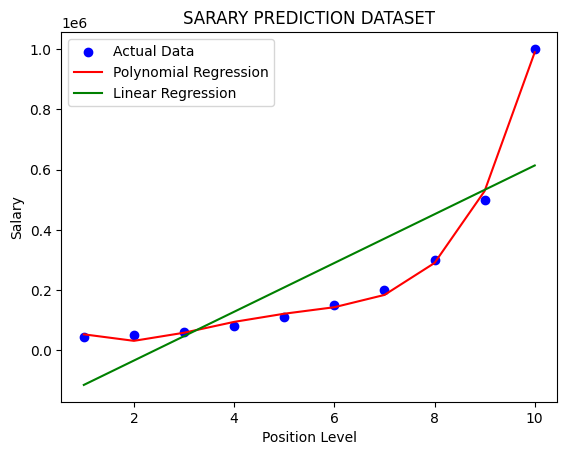

In [ ]:
plt.scatter(X,y,color = 'blue',label = 'Actual Data')
plt.plot(X,poly_reg_model.predict(X_poly),color = 'red', label = 'Polynomial Regression')
plt.plot(X,reg_model.predict(X),color = 'green',label = 'Linear Regression')
plt.title("SARARY PREDICTION DATASET")
plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.legend()
plt.show()

In [ ]:
print(poly_reg_model.predict(poly_reg.fit_transform([[4.87]])))

[118800.60668081]


## Support Vector Regression

In [ ]:
pos_sal = pd.read_csv('Position_Salaries.csv')
print(pos_sal)

            Position  Level   Salary
0   Business Analyst      1    45000
1  Junior Consultant      2    50000
2  Senior Consultant      3    60000
3            Manager      4    80000
4    Country Manager      5   110000
5     Region Manager      6   150000
6            Partner      7   200000
7     Senior Partner      8   300000
8            C-level      9   500000
9                CEO     10  1000000


In [ ]:
X_raw,y_raw = pos_sal.iloc[:,1:-1].values,pos_sal.iloc[:,-1].values
print(X_raw,y_raw)

[[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]] [  45000   50000   60000   80000  110000  150000  200000  300000  500000
 1000000]


In [ ]:
sc_X = StandardScaler()
sc_y = StandardScaler()

X = sc_X.fit_transform(X_raw)
y = sc_y.fit_transform(y_raw.reshape(len(y_raw),-1))
y = y.ravel()
print(X,y)

[[-1.5666989 ]
 [-1.21854359]
 [-0.87038828]
 [-0.52223297]
 [-0.17407766]
 [ 0.17407766]
 [ 0.52223297]
 [ 0.87038828]
 [ 1.21854359]
 [ 1.5666989 ]] [-0.72004253 -0.70243757 -0.66722767 -0.59680786 -0.49117815 -0.35033854
 -0.17428902  0.17781001  0.88200808  2.64250325]


In [ ]:
svr = SVR(kernel = 'rbf')
svr.fit(X,y)

SVR()

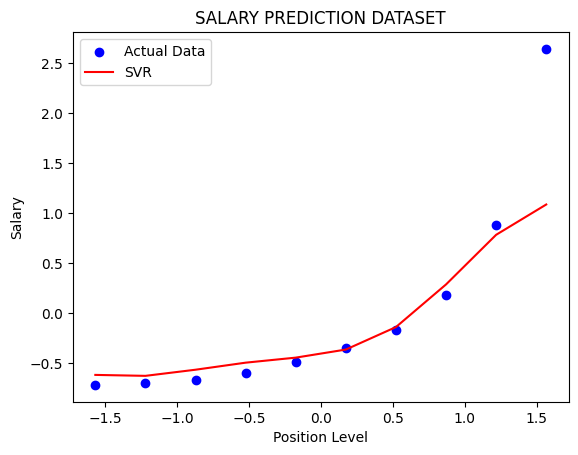

In [ ]:
plt.scatter(X,y,color = 'blue',label = 'Actual Data')
plt.plot(X,svr.predict(X),color = 'red', label = 'SVR')
plt.title("SALARY PREDICTION DATASET")
plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.legend()
plt.show()

In [ ]:
opt = svr.predict(sc_X.transform([[6.5]]))
print(sc_y.inverse_transform(opt.reshape(-1,1)))

[[170370.0204065]]


## Decision Tree

In [ ]:
data = pd.read_csv('Position_Salaries.csv')
print(data)

            Position  Level   Salary
0   Business Analyst      1    45000
1  Junior Consultant      2    50000
2  Senior Consultant      3    60000
3            Manager      4    80000
4    Country Manager      5   110000
5     Region Manager      6   150000
6            Partner      7   200000
7     Senior Partner      8   300000
8            C-level      9   500000
9                CEO     10  1000000


In [ ]:
X,y = data.iloc[:,1:-1].values,data.iloc[:,-1].values
print(X,y)

[[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]] [  45000   50000   60000   80000  110000  150000  200000  300000  500000
 1000000]


In [ ]:
dt_classifier = DecisionTreeRegressor(max_depth=5)
dt_classifier.fit(X,y)

DecisionTreeRegressor(max_depth=5)

In [ ]:
print(dt_classifier.predict([[6.5]]))

[150000.]


/tmp/ipykernel_9643/1533865214.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X),max(X),0.1)


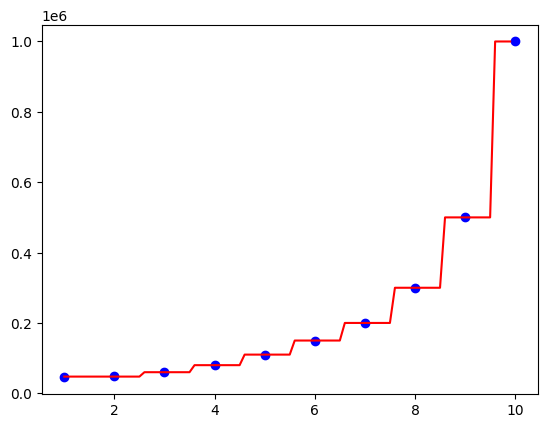

In [ ]:
X_grid = np.arange(min(X),max(X),0.1)
X_grid = x_grid.reshape((len(x_grid),1))
plt.scatter(X,y,color = 'blue',label = 'Actual Data')
plt.plot(X_grid,dt_classifier.predict(X_grid),color = 'red', label = 'Decision Tree')

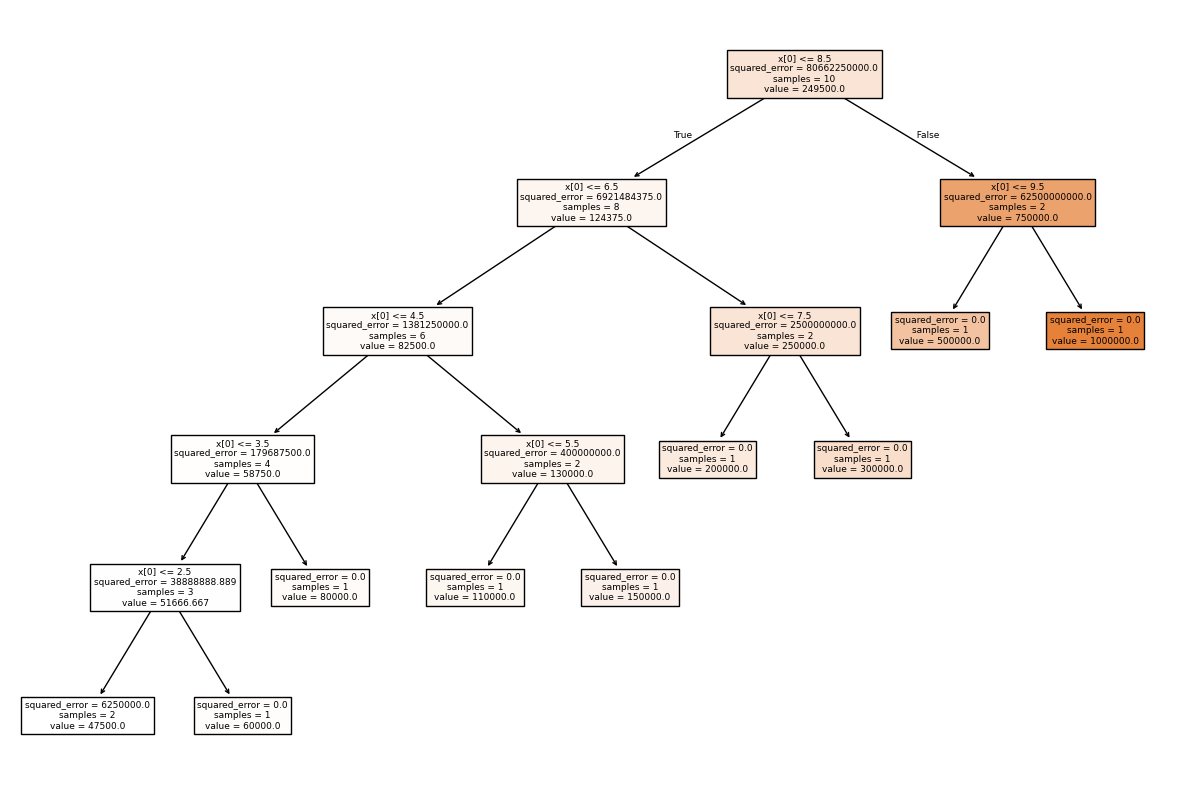

In [ ]:
plt.figure(figsize=(15,10))
plot_tree(dt_classifier,filled=True)
plt.show()

### Another decision tree dataset IRIS

In [ ]:
from sklearn.datasets import load_iris

In [ ]:
print(load_iris())

{'data': array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
     

In [ ]:
iris_dataset = pd.DataFrame(load_iris()['data'], columns = load_iris()['feature_names'])
print(iris_dataset)

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[150 rows x 4 columns]


In [ ]:
# we are just gonna take petal length, petal width
X = iris_dataset.iloc[:,[2,3]].values
y = load_iris()['target']
print(X,y)

[[1.4 0.2]
 [1.4 0.2]
 [1.3 0.2]
 [1.5 0.2]
 [1.4 0.2]
 [1.7 0.4]
 [1.4 0.3]
 [1.5 0.2]
 [1.4 0.2]
 [1.5 0.1]
 [1.5 0.2]
 [1.6 0.2]
 [1.4 0.1]
 [1.1 0.1]
 [1.2 0.2]
 [1.5 0.4]
 [1.3 0.4]
 [1.4 0.3]
 [1.7 0.3]
 [1.5 0.3]
 [1.7 0.2]
 [1.5 0.4]
 [1.  0.2]
 [1.7 0.5]
 [1.9 0.2]
 [1.6 0.2]
 [1.6 0.4]
 [1.5 0.2]
 [1.4 0.2]
 [1.6 0.2]
 [1.6 0.2]
 [1.5 0.4]
 [1.5 0.1]
 [1.4 0.2]
 [1.5 0.2]
 [1.2 0.2]
 [1.3 0.2]
 [1.4 0.1]
 [1.3 0.2]
 [1.5 0.2]
 [1.3 0.3]
 [1.3 0.3]
 [1.3 0.2]
 [1.6 0.6]
 [1.9 0.4]
 [1.4 0.3]
 [1.6 0.2]
 [1.4 0.2]
 [1.5 0.2]
 [1.4 0.2]
 [4.7 1.4]
 [4.5 1.5]
 [4.9 1.5]
 [4.  1.3]
 [4.6 1.5]
 [4.5 1.3]
 [4.7 1.6]
 [3.3 1. ]
 [4.6 1.3]
 [3.9 1.4]
 [3.5 1. ]
 [4.2 1.5]
 [4.  1. ]
 [4.7 1.4]
 [3.6 1.3]
 [4.4 1.4]
 [4.5 1.5]
 [4.1 1. ]
 [4.5 1.5]
 [3.9 1.1]
 [4.8 1.8]
 [4.  1.3]
 [4.9 1.5]
 [4.7 1.2]
 [4.3 1.3]
 [4.4 1.4]
 [4.8 1.4]
 [5.  1.7]
 [4.5 1.5]
 [3.5 1. ]
 [3.8 1.1]
 [3.7 1. ]
 [3.9 1.2]
 [5.1 1.6]
 [4.5 1.5]
 [4.5 1.6]
 [4.7 1.5]
 [4.4 1.3]
 [4.1 1.3]
 [4.  1.3]
 [4.4 1.2]

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=0, test_size = 0.2, shuffle = True )

In [ ]:
print(X_train.shape,y_train.shape,X_test.shape,y_test.shape)

(120, 2) (120,) (30, 2) (30,)


In [ ]:
tree = DecisionTreeClassifier(criterion = 'gini',random_state=0, max_depth = 3)
tree.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=3, random_state=0)

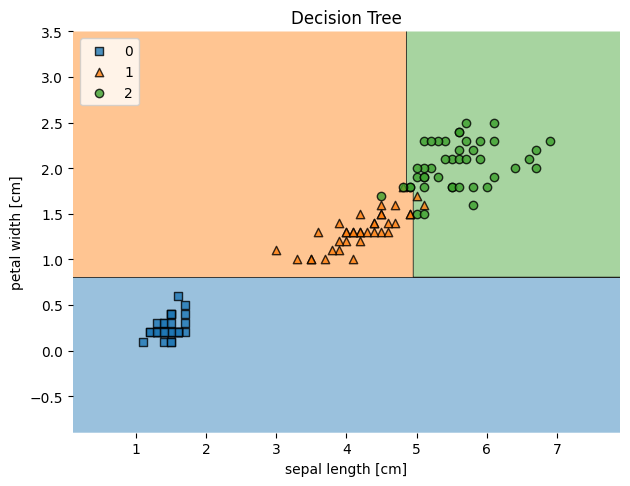

In [ ]:
%matplotlib inline
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X_train, y_train,tree)
plt.xlabel('sepal length [cm]')
plt.ylabel('petal width [cm]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.title('Decision Tree')
plt.show()

In [ ]:
tree.feature_importances_*100

array([ 5.11598335, 94.88401665])

<BarContainer object of 2 artists>

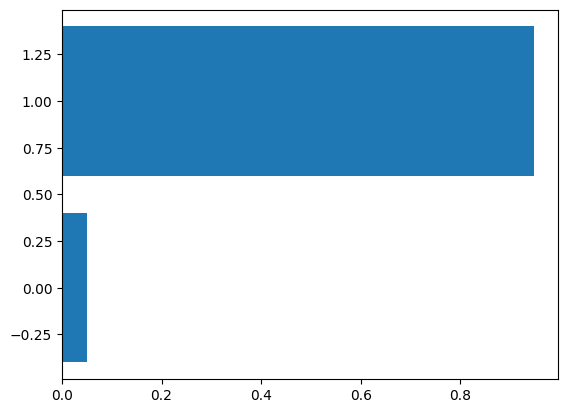

In [ ]:
plt.barh(range(len(tree.feature_importances_)),tree.feature_importances_)

In [ ]:
full_dataset = iris_dataset
full_y = load_iris()['target']
print(full_dataset,full_y)

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[150 rows x 4 columns] [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

In [ ]:
new_classifier = DecisionTreeClassifier(criterion = 'gini',random_state=0, max_depth = 3)
new_classifier.fit(full_dataset,full_y)

DecisionTreeClassifier(max_depth=3, random_state=0)

In [ ]:
new_classifier.feature_importances_*100

array([ 0.        ,  0.        ,  5.39363312, 94.60636688])

In [ ]:
imp_features = pd.DataFrame({
    'features':full_dataset.columns,
    'importance':new_classifier.feature_importances_
}).sort_values('importance',ascending=False)
print(imp_features)

            features  importance
3   petal width (cm)    0.946064
2  petal length (cm)    0.053936
1   sepal width (cm)    0.000000
0  sepal length (cm)    0.000000


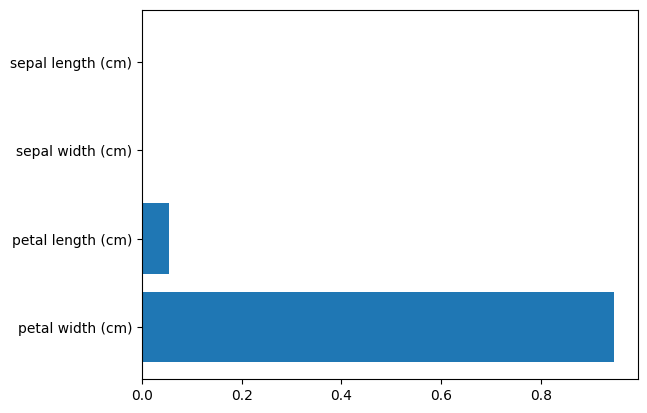

In [ ]:
plt.barh(imp_features['features'],imp_features['importance'])
plt.show()

In [ ]:
final_features = imp_features[imp_features['importance']>0.05]
print(final_features)

            features  importance
3   petal width (cm)    0.946064
2  petal length (cm)    0.053936


In [ ]:
X_reduced = full_dataset[final_features['features']]
print(X_reduced)

     petal width (cm)  petal length (cm)
0                 0.2                1.4
1                 0.2                1.4
2                 0.2                1.3
3                 0.2                1.5
4                 0.2                1.4
..                ...                ...
145               2.3                5.2
146               1.9                5.0
147               2.0                5.2
148               2.3                5.4
149               1.8                5.1

[150 rows x 2 columns]


## Random Forest 🌲🌲

### Position salaries dataset

In [ ]:
dataset = pd.read_csv('Position_Salaries.csv')
print(dataset)

            Position  Level   Salary
0   Business Analyst      1    45000
1  Junior Consultant      2    50000
2  Senior Consultant      3    60000
3            Manager      4    80000
4    Country Manager      5   110000
5     Region Manager      6   150000
6            Partner      7   200000
7     Senior Partner      8   300000
8            C-level      9   500000
9                CEO     10  1000000


In [ ]:
X,y = dataset.iloc[:,1:-1].values,dataset.iloc[:,-1].values
print(X,y)

[[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]] [  45000   50000   60000   80000  110000  150000  200000  300000  500000
 1000000]


In [ ]:
RandomForestRegressor?

In [ ]:
regressor = RandomForestRegressor(n_estimators=10,random_state=0)

In [ ]:
regressor.fit(X,y)

RandomForestRegressor(n_estimators=10, random_state=0)

/tmp/ipykernel_2634/2848745923.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X),max(X),0.1)


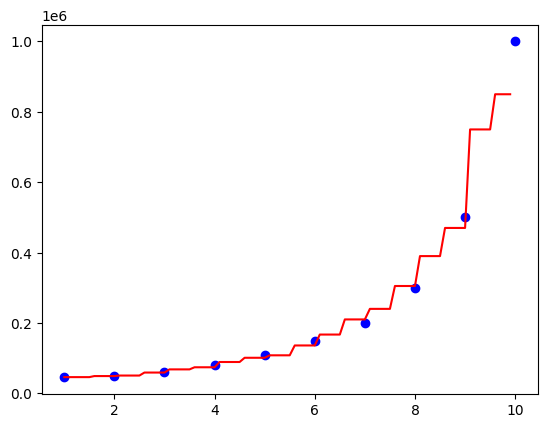

In [ ]:
X_grid = np.arange(min(X),max(X),0.1)
X_grid = X_grid.reshape((len(X_grid),1))
plt.scatter(X,y,color = 'blue',label = 'Actual Data')
plt.plot(X_grid,regressor.predict(X_grid),color = 'red', label = 'Random Forest')
plt.show()

### Random Forest on Breast Cancer Datasets

In [2]:
from sklearn.datasets import load_breast_cancer

new_dataset = load_breast_cancer()
print(new_dataset)

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]]), 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
 

In [3]:
data = pd.DataFrame(new_dataset['data'],columns = new_dataset['feature_names'])
print(data)

     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0          17.99         10.38          122.80     1001.0          0.11840   
1          20.57         17.77          132.90     1326.0          0.08474   
2          19.69         21.25          130.00     1203.0          0.10960   
3          11.42         20.38           77.58      386.1          0.14250   
4          20.29         14.34          135.10     1297.0          0.10030   
..           ...           ...             ...        ...              ...   
564        21.56         22.39          142.00     1479.0          0.11100   
565        20.13         28.25          131.20     1261.0          0.09780   
566        16.60         28.08          108.30      858.1          0.08455   
567        20.60         29.33          140.10     1265.0          0.11780   
568         7.76         24.54           47.92      181.0          0.05263   

     mean compactness  mean concavity  mean concave points  mea

In [4]:
y = new_dataset['target']
print(y)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 0 0 1 1 1 1 0 1 0 0
 1 0 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1 0 1 1 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 1 1
 1 1 1 1 1 1 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 1 0 0 1 1 1 1 0 1 1 0 0 0 1 0
 1 0 1 1 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 0 1 0 0 0 0 1 1 0 0 1 1
 1 0 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 1 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 1 1 1 1 0 1 0 1 1 0 1 1 0 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 0 1 1 1 1 0 0 0 1 1
 1 1 0 1 0 1 0 1 1 1 0 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 0
 0 1 0 0 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 0 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1
 1 0 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 1 0 1 1 1 1 1 0 1 1
 0 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1
 1 1 1 1 1 1 0 1 0 1 1 0 

In [5]:
model = RandomForestClassifier(n_estimators=100,random_state=20)

In [6]:
model.fit(data,y)

RandomForestClassifier(random_state=20)

In [7]:
model.feature_importances_

array([0.05687597, 0.01581821, 0.01328037, 0.04637739, 0.00483739,
       0.01324228, 0.04691099, 0.09096191, 0.00506443, 0.00383226,
       0.00969035, 0.00574434, 0.02282721, 0.03327648, 0.00455719,
       0.00389727, 0.00576638, 0.003144  , 0.00357597, 0.00478372,
       0.11206832, 0.01290564, 0.16128989, 0.12000762, 0.0154794 ,
       0.01088165, 0.04792218, 0.10572291, 0.01171559, 0.00754269])

In [8]:
feature_score = pd.DataFrame({
    'features':data.columns,
    'score':model.feature_importances_
}).sort_values('score',ascending=False)
print(feature_score)

                   features     score
22          worst perimeter  0.161290
23               worst area  0.120008
20             worst radius  0.112068
27     worst concave points  0.105723
7       mean concave points  0.090962
0               mean radius  0.056876
26          worst concavity  0.047922
6            mean concavity  0.046911
3                 mean area  0.046377
13               area error  0.033276
12          perimeter error  0.022827
1              mean texture  0.015818
24         worst smoothness  0.015479
2            mean perimeter  0.013280
5          mean compactness  0.013242
21            worst texture  0.012906
28           worst symmetry  0.011716
25        worst compactness  0.010882
10             radius error  0.009690
29  worst fractal dimension  0.007543
16          concavity error  0.005766
11            texture error  0.005744
8             mean symmetry  0.005064
4           mean smoothness  0.004837
19  fractal dimension error  0.004784
14         s

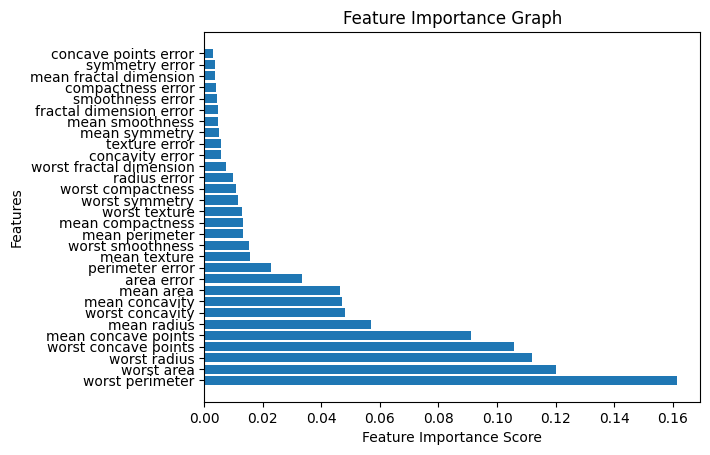

In [9]:
plt.barh(feature_score['features'],feature_score['score'])
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title('Feature Importance Graph')
plt.show()

In [10]:
useful_features = feature_score[feature_score['score']>0.02]
X_reduced = data[useful_features['features']]
print(X_reduced)

     worst perimeter  worst area  worst radius  worst concave points  \
0             184.60      2019.0        25.380                0.2654   
1             158.80      1956.0        24.990                0.1860   
2             152.50      1709.0        23.570                0.2430   
3              98.87       567.7        14.910                0.2575   
4             152.20      1575.0        22.540                0.1625   
..               ...         ...           ...                   ...   
564           166.10      2027.0        25.450                0.2216   
565           155.00      1731.0        23.690                0.1628   
566           126.70      1124.0        18.980                0.1418   
567           184.60      1821.0        25.740                0.2650   
568            59.16       268.6         9.456                0.0000   

     mean concave points  mean radius  worst concavity  mean concavity  \
0                0.14710        17.99           0.7119       

## Using Multiple Classifiers to get the best Accuracy Results

In [11]:
from sklearn.model_selection import GridSearchCV

params = {
    'RandomForestClassifier':{
        'model':RandomForestClassifier(),
        'params':{
            'n_estimators':[10,100],
            'max_depth':[None,10]
        }
    },
    'LogisticRegression':{
        'model': Pipeline([
            ('scaler', StandardScaler()),
            ('logisticregression', LogisticRegression())
        ]),
        'params':{
            'logisticregression__C':[1,5,10]
        }
    },
    'SVC':{
        'model': Pipeline([
            ('scaler', StandardScaler()),
            ('svc', SVC())
        ]),
        'params':{
            'svc__C':[1,5,10],
            'svc__kernel':['rbf','linear']
        }
    },
    'KNN':{
        'model':Pipeline([
            ('scaler',StandardScaler()),
            ('knn',KNeighborsClassifier())
        ]),
        'params':{
            'knn__n_neighbors':[3,5,10],
            'knn__metric':['euclidean','manhattan'],
            'knn__p':[1,2]
        }
    }
}
## Remember pipeline_name + params scv + C == svc__C short trick

In [12]:
scores = []
fitted_clfs = {} # Dictionary to store fitted GridSearchCV objects

for model_name,param_data in params.items():
    clf = GridSearchCV(param_data['model'],param_data['params'],cv=5,return_train_score=False)
    clf.fit(X_reduced,y)

    scores.append({
        'model':model_name,
        'best_score':clf.best_score_,
        'best_params':clf.best_params_
    })
    fitted_clfs[model_name] = clf # Store the fitted GridSearchCV object

print(scores)

[{'model': 'RandomForestClassifier', 'best_score': np.float64(0.943797546964757), 'best_params': {'max_depth': None, 'n_estimators': 100}}, {'model': 'LogisticRegression', 'best_score': np.float64(0.9490607048594939), 'best_params': {'logisticregression__C': 10}}, {'model': 'SVC', 'best_score': np.float64(0.956078248719143), 'best_params': {'svc__C': 10, 'svc__kernel': 'rbf'}}, {'model': 'KNN', 'best_score': np.float64(0.94027324949542), 'best_params': {'knn__metric': 'euclidean', 'knn__n_neighbors': 10, 'knn__p': 1}}]


In [13]:
metrics_board  = pd.DataFrame(scores,columns = ['model','best_score','best_params'])
print(metrics_board)

                    model  best_score  \
0  RandomForestClassifier    0.943798   
1      LogisticRegression    0.949061   
2                     SVC    0.956078   
3                     KNN    0.940273   

                                         best_params  
0           {'max_depth': None, 'n_estimators': 100}  
1                      {'logisticregression__C': 10}  
2               {'svc__C': 10, 'svc__kernel': 'rbf'}  
3  {'knn__metric': 'euclidean', 'knn__n_neighbors...  


In [14]:
pd.set_option('display.max_colwidth', None)
print(metrics_board)

                    model  best_score  \
0  RandomForestClassifier    0.943798   
1      LogisticRegression    0.949061   
2                     SVC    0.956078   
3                     KNN    0.940273   

                                                         best_params  
0                           {'max_depth': None, 'n_estimators': 100}  
1                                      {'logisticregression__C': 10}  
2                               {'svc__C': 10, 'svc__kernel': 'rbf'}  
3  {'knn__metric': 'euclidean', 'knn__n_neighbors': 10, 'knn__p': 1}  


### Using the best estimator for prediction

In [15]:
if 'SVC' in fitted_clfs:
    best_svc_estimator = fitted_clfs['SVC'].best_estimator_
    print(f"Best SVC Estimator: {best_svc_estimator}")

    sample_for_prediction = X_reduced.iloc[[0]] # Get the first sample as a DataFrame row
    predicted_class = best_svc_estimator.predict(sample_for_prediction)
    print(f"Predicted class for the first sample: {predicted_class[0]}")
else:
    print("SVC GridSearchCV object not found in fitted_clfs.")

Best SVC Estimator: Pipeline(steps=[('scaler', StandardScaler()), ('svc', SVC(C=10))])
Predicted class for the first sample: 0


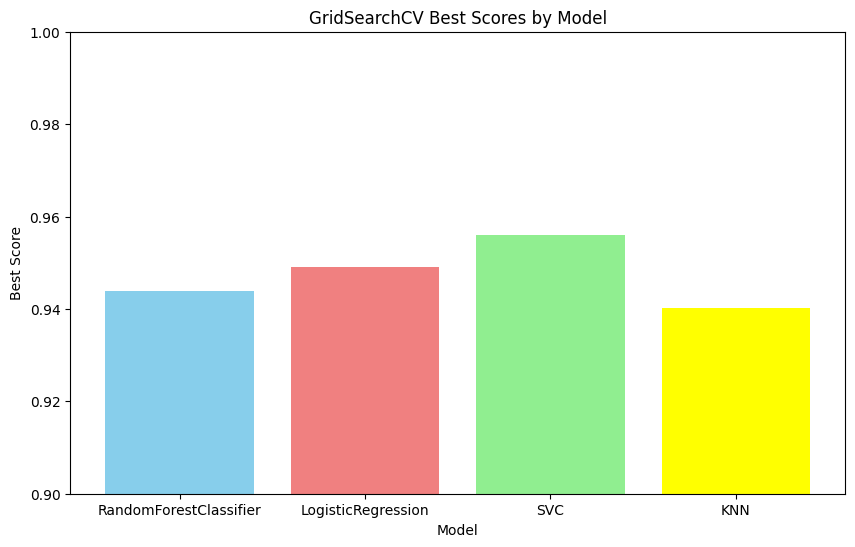

In [16]:
plt.figure(figsize=(10, 6))
plt.bar(metrics_board['model'], metrics_board['best_score'], color=['skyblue', 'lightcoral', 'lightgreen', 'yellow' ])
plt.xlabel('Model')
plt.ylabel('Best Score')
plt.title('GridSearchCV Best Scores by Model')
plt.ylim(0.9, 1.0) # y-axis limit to better visualize differences
plt.show()

# AI generated code for Visualising the data features and Boundary

Generating decision boundaries for 6 feature pairs...


  0%|          | 0/6 [00:00<?, ?it/s]

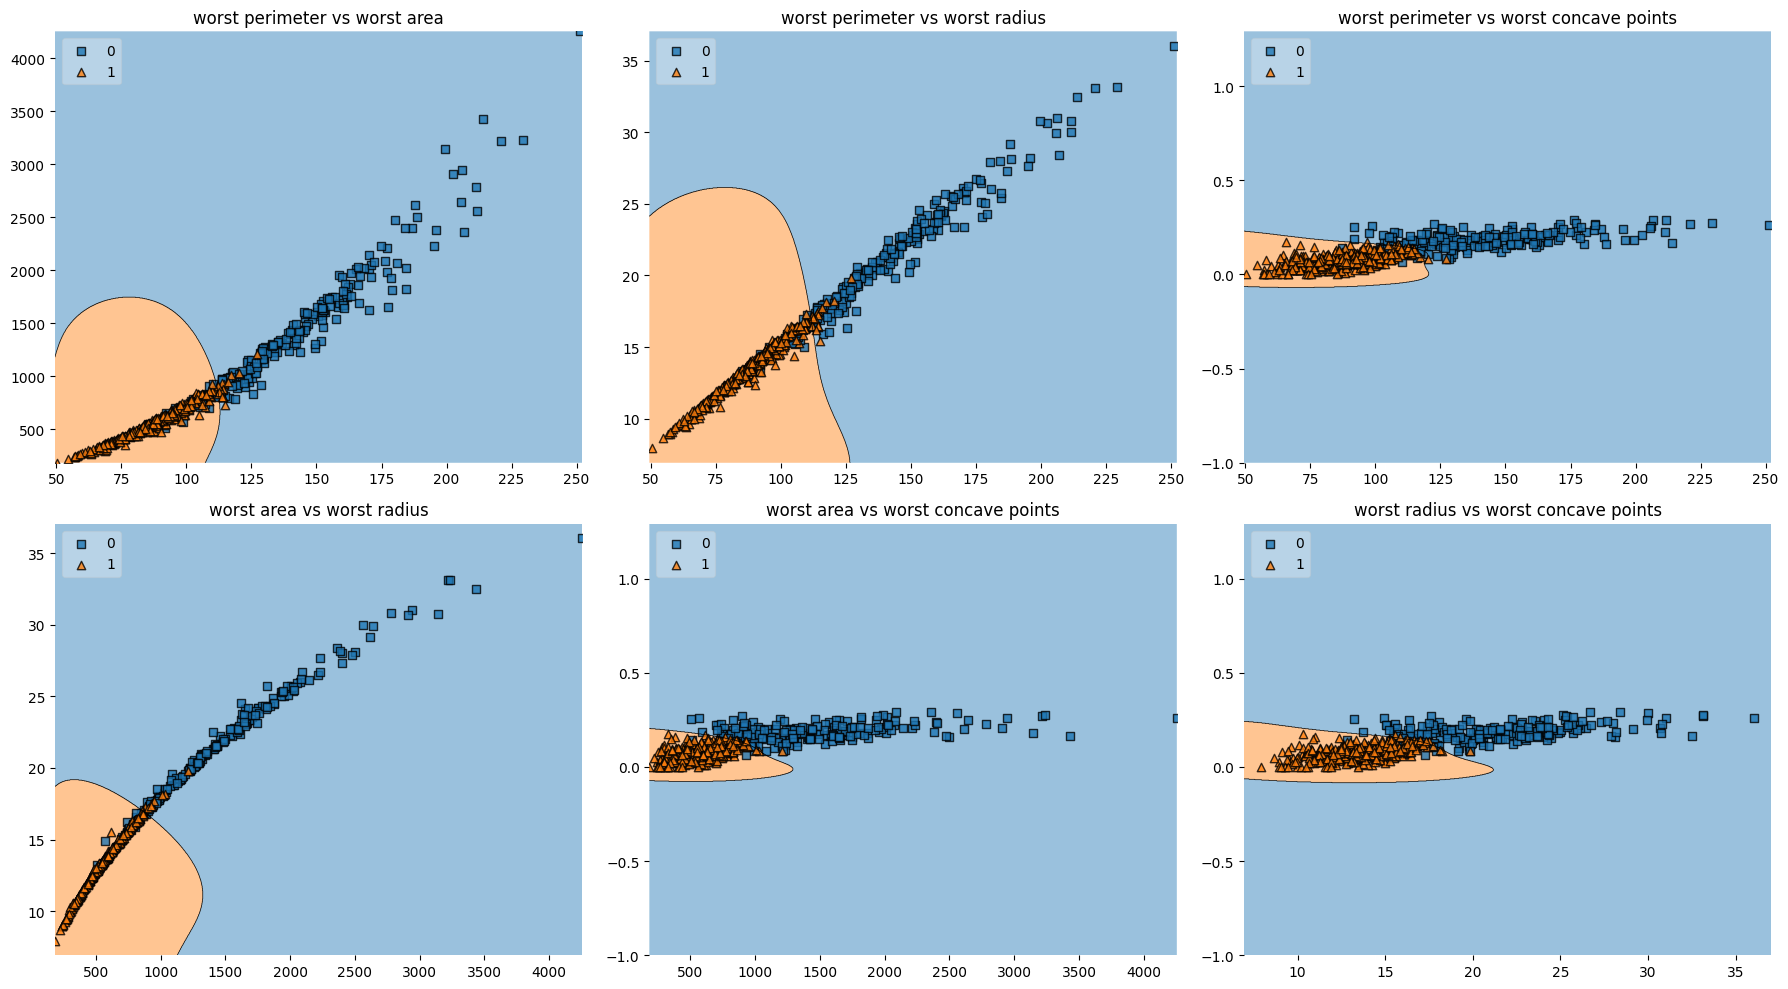

In [17]:
from itertools import combinations
from mlxtend.plotting import plot_decision_regions
from tqdm.notebook import tqdm
import math

# Selecting the top 4 features to keep the number of plots (6) manageable and fast
top_features = useful_features['features'].iloc[:4].tolist()
X_top = X_reduced[top_features]

feature_combinations = list(combinations(range(len(top_features)), 2))
num_combinations = len(feature_combinations)
num_cols = 3
num_rows = math.ceil(num_combinations / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, num_rows * 5))
axes = axes.flatten()

# Best params from your previous GridSearch
best_svc_params = fitted_clfs['SVC'].best_params_
svc_C = best_svc_params['svc__C']
svc_kernel = best_svc_params['svc__kernel']

print(f"Generating decision boundaries for {num_combinations} feature pairs...")

# Using tqdm as a progress loader
for i, (idx1, idx2) in enumerate(tqdm(feature_combinations)):
    current_features = [top_features[idx1], top_features[idx2]]
    X_pair = X_top[current_features].values

    # We fit a 2D version of your best model here so the decision boundary
    # can be drawn accurately on a 2D plane.
    svc_viz = Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(C=svc_C, kernel=svc_kernel))
    ]).fit(X_pair, y)

    plot_decision_regions(X_pair, y, clf=svc_viz, legend=2, ax=axes[i])
    axes[i].set_title(f'{current_features[0]} vs {current_features[1]}')

# Remove empty subplots
for j in range(num_combinations, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()